# Predicting Continuous Target Variables With Regression Analysis

Ames Housing dataset contains informatiuon abuot individual residential property in Ames, Iowa from 2006 to 2010.

The dataset consists of 2930 examples and 80 features. For the simplicity of analysis, we will only work with a subset of the features.

The features we will be working with, including the target variable, are as follows:
- Overall Qual: Rating for the overall material and finish of the house on a scale from 1 (very
poor) to 10 (excellent)
- Overall Cond: Rating for the overall condition of the house on a scale from 1 (very poor) to
10 (excellent)
- Gr Liv Area: Above grade (ground) living area in square feet
- Central Air: Central air conditioning (N=no, Y=yes)
- Total Bsmt SF: Total square feet of the basement area
- SalePrice: Sale price in U.S. dollars ($)

In [1]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 
           'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt', sep='\t', usecols=columns)

df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [2]:
df.shape

(2930, 6)

In [3]:
df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})

In [4]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [5]:
df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

## Visualising Important Characteristics of a Dataset

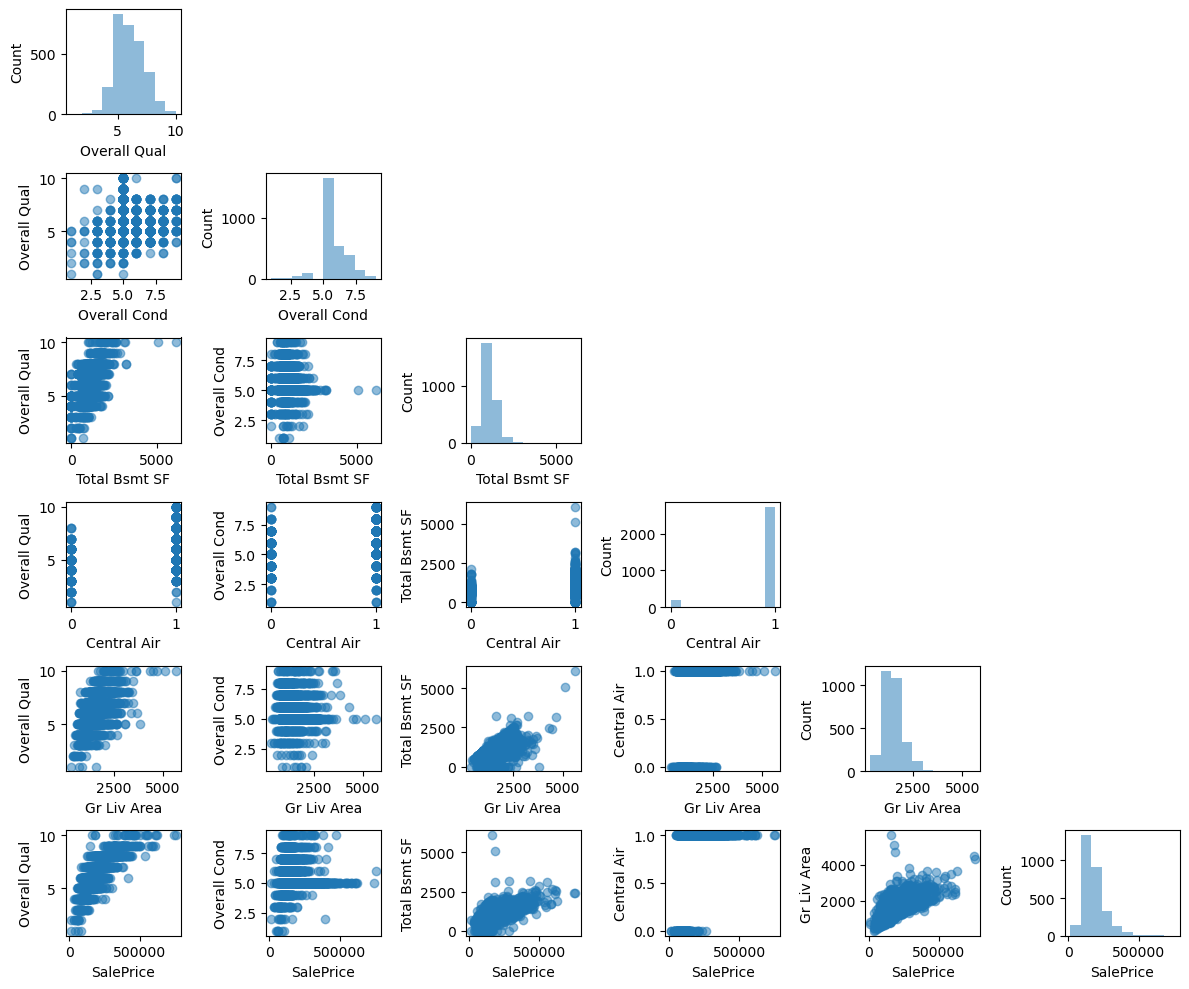

In [6]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize=(12, 10), names=df.columns, alpha=0.5);

plt.tight_layout()
plt.savefig('figures/10_01.png', dpi=300)
plt.show()

## Relationships Using Correlation Matrix

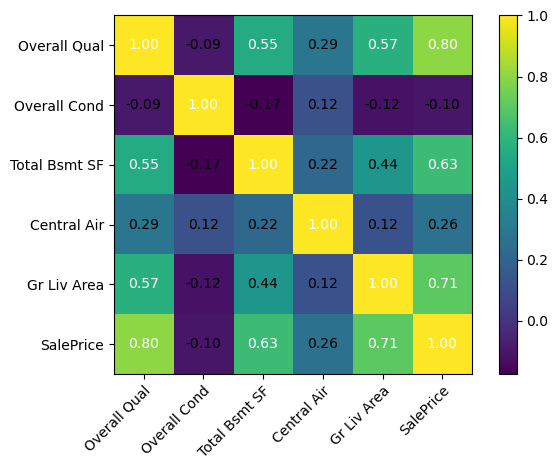

In [7]:
import numpy as np
from mlxtend.plotting import heatmap

cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)

plt.tight_layout()
plt.savefig('figures/10_02.png', dpi=300)
plt.show()

## Ordinary Least Squares (OLS)

### Regression Parameters with Gradient Descent

In [8]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

Now we use `LinearRegressionGD` regressor to fit the model. We're gonna use `Gr Living Area` as the feature and `SalePrice` as the target variable.

In [9]:
from sklearn.preprocessing import StandardScaler

X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()

lr = LinearRegressionGD(eta=0.1)
lr.fit(X_std, y_std)

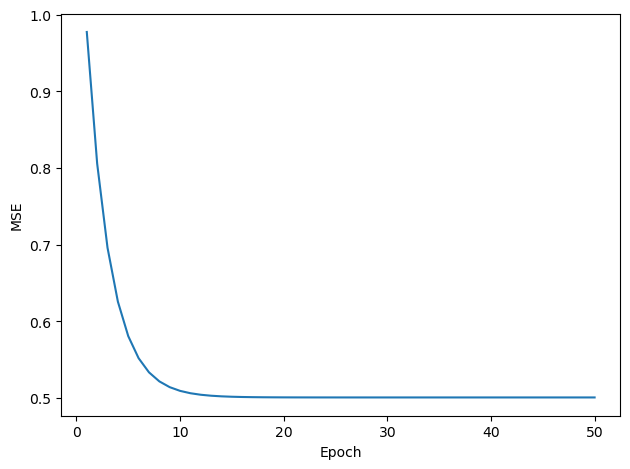

In [10]:
plt.plot(range(1, lr.n_iter+1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')

plt.tight_layout()
plt.savefig('figures/10_03.png', dpi=300)
plt.show()

GD algorithm converged around tenth epoch

Now we want to visualise how well the linear regression line fits the data.

In [11]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)

Now we use it to plot the living area against the sale price.

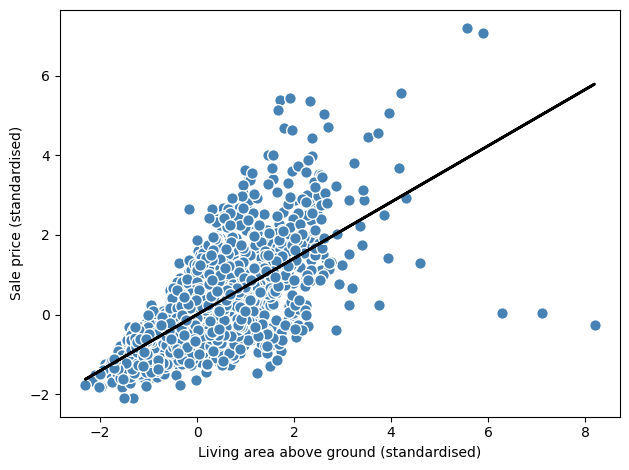

In [12]:
lin_regplot(X_std, y_std, lr)
plt.xlabel('Living area above ground (standardised)')
plt.ylabel('Sale price (standardised)')
plt.tight_layout()
plt.savefig('figures/10_04.png', dpi=300)
plt.show()

In some cases, it's important to report the predicted outcomes variables on their original scale. This is called inverse transformation. We will predict an aboveground living area of 2,500 square feet and find it's predicted sale price. 

In [13]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))

print(f'Sales price: ${target_reverted.flatten()[0]:.2f}')

Sales price: $292507.07


We technically don't have to update the intercept parameter (b) if we are working with standardised variables, since y axis intercept is always 0.

In [14]:
print(f'Slope: {lr.w_[0]:.3f}')
print(f'Intercept: {lr.b_[0]:.3f}')

Slope: 0.707
Intercept: -0.000


### Estimating coefficient of a regression model via Scikit-Learn

Many of scikit-learn’s estimators for regression make use of the least squares implementation in SciPy (scipy.linalg.lstsq), which, in turn, uses highly optimised code optimisations based on the Linear Algebra Package (LAPACK). The linear regression implementation in scikit-learn also works (better) with unstandardised variables, since it does not use (S)GD-based optimisation, so we can skip the standardisation step

In [15]:
from sklearn.linear_model import LinearRegression

slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)

print(f'Slope: {slr.coef_[0]:.3f}')
print(f'Intercept: {slr.intercept_:.3f}')

Slope: 111.666
Intercept: 13342.979


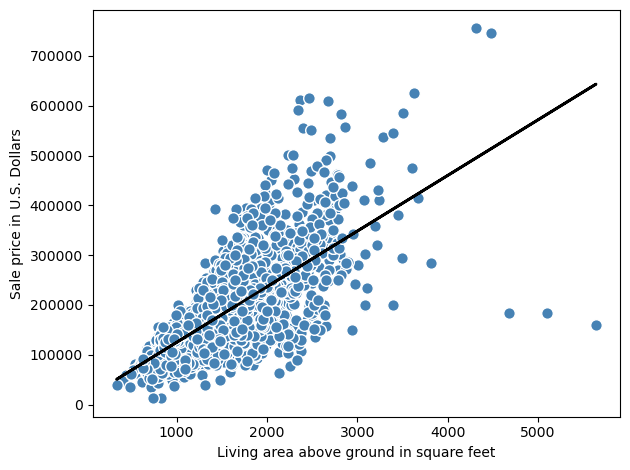

In [16]:
lin_regplot(X, y, slr)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. Dollars')
plt.tight_layout()
plt.savefig('figures/10_05.png', dpi=300)
plt.show()

Closed-form solution for solving OLS, involving a system of linear equations.

In [17]:
# adding a column vector of "ones"
Xb = np.hstack((np.ones((X.shape[0], 1)), X))
w = np.zeros(X.shape[1])
z = np.linalg.inv(np.dot(Xb.T, Xb))
w = np.dot(z, np.dot(Xb.T, y))

print(f'Slope: {w[1]:.3f}')
print(f'Intercept: {w[0]:.3f}')

Slope: 111.666
Intercept: 13342.979


### Fitting a robust regression model using RANSAC

In [18]:
from sklearn.linear_model import RANSACRegressor

ransac = RANSACRegressor(
    LinearRegression(),
    max_trials=100, # default
    min_samples=0.95,
    residual_threshold=None, # default
    random_state=123
)

ransac.fit(X, y)

,estimator,LinearRegression()
,min_samples,0.95
,residual_threshold,None
,is_data_valid,None
,is_model_valid,None
,max_trials,100
,max_skips,inf
,stop_n_inliers,inf
,stop_score,inf
,stop_probability,0.99
,loss,'absolute_error'


- `max_trials`: Maximum number of iterations = 100
- `min_samples`: Minimum number of randomly chosen training examples to be at least 95 percent of the dataset.
- `residual_threshold`: Scikit-Learn uses the MAD (Median Absolute Deviation) to calculate the residual threshold.

Now we obtain the inliers and outliers from the fitted RANSAC model and plot them.

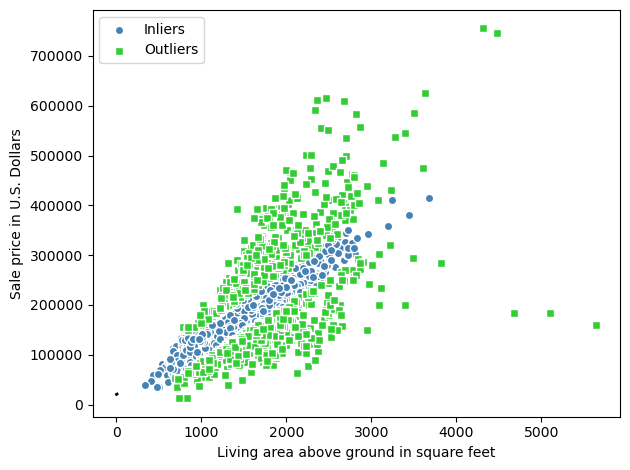

In [19]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)
line_X = np.arange(3, 10, 1)
lint_y_ransac = ransac.predict(line_X[:, np.newaxis])

plt.scatter(X[inlier_mask], y[inlier_mask], c='steelblue', edgecolor='white', marker='o', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], c='limegreen', edgecolor='white', marker='s', label='Outliers')
plt.plot(line_X, lint_y_ransac, color='black', lw=2)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. Dollars')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/10_06.png', dpi=300)
plt.show()

In [20]:
print(f'Slope: {ransac.estimator_.coef_[0]:.3f}')
print(f'Intercept: {ransac.estimator_.intercept_:.3f}')


Slope: 106.348
Intercept: 20190.093


MAD, for this dataset, computed as:

In [21]:
def mean_absolute_deviation(data):
    return np.mean(np.abs(data - np.mean(data)))
mean_absolute_deviation(y)

np.float64(58269.561754979375)

If we want to identify fewer data points as outliers, we can choose a `residual_threshold` that is higher than the preceding MAD.

## Evaluating The Performance Of Linear Regression Models

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

target = 'SalePrice'
features = df.columns[df.columns != target]

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123)

slr = LinearRegression()

slr.fit(X_train, y_train)

y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

We will plot the residuals (the differences or vertical distances between the actual and predicted values) to check for patterns or trends.

Now we plot the residual plot where we subtract the predicted values from the actual values:

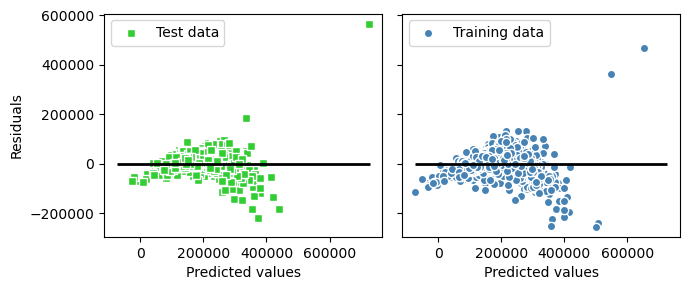

In [23]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test,
            c='limegreen', marker='s', edgecolor='white',
            label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train,
            c='steelblue', marker='o', edgecolor='white',
            label='Training data')
ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='black', lw=2)

plt.tight_layout()

plt.savefig('figures/10_07.png', dpi=300)
plt.show()

MSE (Mean Squared Error) to measure the performance of the model.

In [24]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f'MSE train: {mse_train:.2f}')
print(f'MSE test: {mse_test:.2f}')

MSE train: 1497216245.85
MSE test: 1516565821.00


MSE on training dataset is larger than on the test set, which is an inidicator of overfitting.

Better here to use MAE (Mean Absolute Error) as we may choose to compute the square root of the MSE, which emphasizes incorrect predictions slightly less:

In [25]:
from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"MAE Train: {mae_train:.2f}")
print(f"MAE Test: {mae_test:.2f}")

MAE Train: 25983.03
MAE Test: 24921.29


Based on MAE, model makes an error of approximately $25,000 on average.

In [26]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'R^2 train: {train_r2:.3f}, {test_r2:.3f}')

R^2 train: 0.769, 0.752


## Regularised Methods for Regression

### Ridge Regression

In [27]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

### Lasso

In [28]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

### Elastic Net

In [29]:
from sklearn.linear_model import ElasticNet

elanet = ElasticNet(alpha=1.0, l1_ratio=0.5)

## Turning a Linear Regression Model Into a Curve - Polynomial Regression

### Polynomial Terms Using Scikit-Learn

Use `PolynomialFeatures` to add quadratic term `(d=2)` to simple regression model with one explanatory variable.

Second-degree polynomial term:

In [30]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([258.0, 270.0, 294.0, 320.0, 342.0,
              368.0, 396.0, 446.0, 480.0, 586.0])\
             [:, np.newaxis]

y = np.array([236.4, 234.4, 252.8, 298.6, 314.2,
              342.2, 360.8, 368.0, 391.2, 390.8])

lr = LinearRegression()
pr = LinearRegression()
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X)

Fit linear regression for comparison:

In [31]:
lr.fit(X, y)
X_fit = np.arange(250, 600, 10)[:, np.newaxis]
y_lin_fit = lr.predict(X_fit)

Fit multiple regression model on transformed features for polynomial regression:

In [32]:
pr.fit(X_quad, y)
y_quad_fit = pr.predict(quadratic.fit_transform(X_fit))

Plot results:

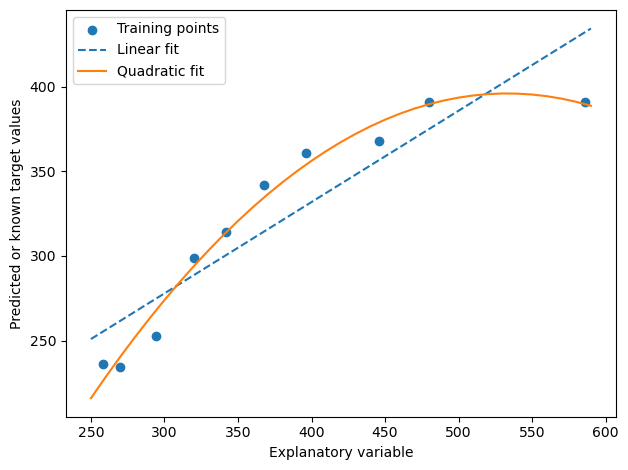

In [33]:
plt.scatter(X, y, label='Training points')
plt.plot(X_fit, y_lin_fit, label='Linear fit', linestyle='--')
plt.plot(X_fit, y_quad_fit, label='Quadratic fit')
plt.xlabel('Explanatory variable')
plt.ylabel('Predicted or known target values')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/10_08.png', dpi=300)
plt.show()

`MSE` and `R^2` evaluation metrics:

In [34]:
y_lin_pred = lr.predict(X)
y_quad_pred = pr.predict(X_quad)
mse_lin = mean_squared_error(y, y_lin_pred)
mse_quad = mean_squared_error(y, y_quad_pred)

print(f'Training MSE linear: {mse_lin:.3f}'
      f', quadratic: {mse_quad:.3f}')

r2_lin = r2_score(y, y_lin_pred)
r2_quad = r2_score(y, y_quad_pred)

print(f'Training R^2 linear: {r2_lin:.3f}'
      f', quadratic: {r2_quad:.3f}')

Training MSE linear: 569.780, quadratic: 61.330
Training R^2 linear: 0.832, quadratic: 0.982


## Modelling Nonlinear Relationships In The Ames Housing Dataset

Model relationship between sale price and living area above ground using second-degree (quadractic) and third-degree (cubic) polynomials

Fit regression models:

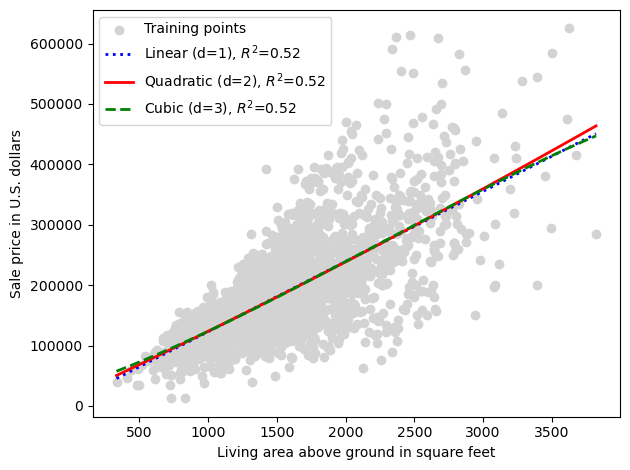

In [35]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

X = X[(df['Gr Liv Area'] < 4000)]
y = y[(df['Gr Liv Area'] < 4000)]

regr = LinearRegression()

# create quadratic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)

# fit features
X_fit = np.arange(X.min()-1, X.max()+2, 1)[:, np.newaxis]

regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))

regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))

regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))


# plot results
plt.scatter(X, y, label='Training points', color='lightgray')

plt.plot(X_fit, y_lin_fit, 
         label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue', 
         lw=2, 
         linestyle=':')

plt.plot(X_fit, y_quad_fit, 
         label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red', 
         lw=2,
         linestyle='-')

plt.plot(X_fit, y_cubic_fit, 
         label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green', 
         lw=2,
         linestyle='--')


plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/10_09.png', dpi=300)
plt.show()

Try again with different features, `Overall Qual` and `Sale Price`.

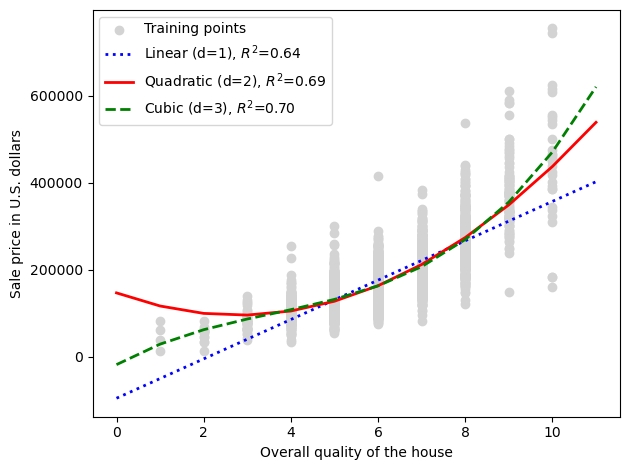

In [36]:
X = df[['Overall Qual']].values
y = df['SalePrice'].values

# X = X[(df['Gr Liv Area'] < 4000)]
# y = y[(df['Gr Liv Area'] < 4000)]

regr = LinearRegression()

# create quadratic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)

# fit features
X_fit = np.arange(X.min()-1, X.max()+2, 1)[:, np.newaxis]

regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))

regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))
quadratic_r2 = r2_score(y, regr.predict(X_quad))

regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))


# plot results
plt.scatter(X, y, label='Training points', color='lightgray')

plt.plot(X_fit, y_lin_fit, 
         label=f'Linear (d=1), $R^2$={linear_r2:.2f}',
         color='blue', 
         lw=2, 
         linestyle=':')

plt.plot(X_fit, y_quad_fit, 
         label=f'Quadratic (d=2), $R^2$={quadratic_r2:.2f}',
         color='red', 
         lw=2,
         linestyle='-')

plt.plot(X_fit, y_cubic_fit, 
         label=f'Cubic (d=3), $R^2$={cubic_r2:.2f}',
         color='green', 
         lw=2,
         linestyle='--')


plt.xlabel('Overall quality of the house')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/10_10.png', dpi=300)
plt.show()

## Nonlinear relationships using random forests

### Decision tree regression

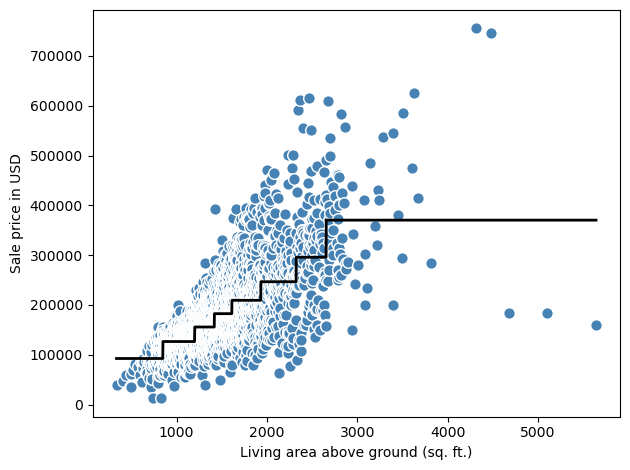

In [38]:
from sklearn.tree import DecisionTreeRegressor

X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)
sort_idx = X.flatten().argsort()
lin_regplot(X[sort_idx], y[sort_idx], tree)
plt.xlabel('Living area above ground (sq. ft.)')
plt.ylabel('Sale price in USD')

plt.tight_layout()
plt.savefig('figures/10_11.png', dpi=300)
plt.show()

Plot does a good job of capturing the general trend of the data, but a limitation with this model is that it doesn't capture the continuous nature of the data.

### Random Forest Regression

In [39]:
from sklearn.ensemble import RandomForestRegressor

target = 'SalePrice'
features = df.columns[df.columns != target]

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

forest = RandomForestRegressor(n_estimators=1000, criterion='squared_error', random_state=1, n_jobs=-1)
forest.fit(X_train, y_train)

y_train_pred = forest.predict(X_train)
y_test_pred = forest.predict(X_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"MAE (train): {mae_train:.2f}")
print(f"MAE (test): {mae_test:.2f}")

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R² (train): {r2_train:.2f}")
print(f"R² (test): {r2_test:.2f}")

MAE (train): 8305.26
MAE (test): 20823.86
R² (train): 0.98
R² (test): 0.85


Random forests tend to overfit the training data.

Looking at the residuals of the prediction:

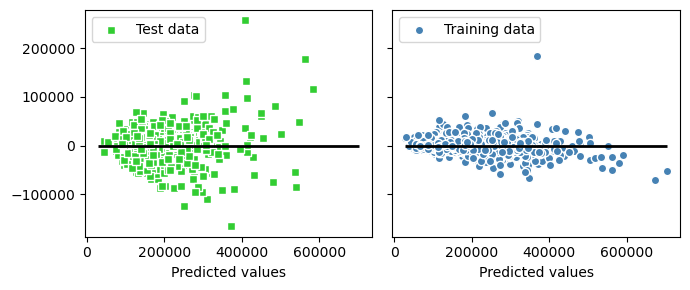

In [40]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
ax1.scatter(y_test_pred, y_test_pred - y_test, c='limegreen', marker='s', edgecolor='white', label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train, c='steelblue', marker='o', edgecolor='white', label='Training data')

for ax in (ax1, ax2):
    ax.set_xlabel('Predicted values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, colors='black', lw=2)

plt.tight_layout()
plt.savefig('figures/10_12.png', dpi=300)
plt.show()